# Error Normalized Distance Simulations
A first study of the ideal error normalized distance distributions was done in 'crossmatch_analysis.ipynb'

In this notebook, we include all code and plots to study how error normalized distributions should behave, and change under varying distances and covariances

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import own modules
import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')

from plotting_functions import set_styles
from astrometry_equations import rayleigh, compute_error_normalized_distance
set_styles()

# Simulate

In [39]:
# MOVE SOMEWHERE ELSE
def simulate_error_normalized_distance(dist_mean1, dist_mean2, unc1, unc2, num_samples, method='full'):
    """Simulates num_samples pairs of data points and computes the error normalized distances between them

    TODO: Expand documentation, expand flexibility of code"""

    if len(dist_mean1) == 2:
        # Should check here if we have just 2 vals, or an array of vals
        pass

    if len(unc1) == 3:
        # Check here if all points have same spread, or if it varies
        sigma_x1, sigma_y1, sigma_xy1 = unc1
        sigma_x2, sigma_y2, sigma_xy2 = unc2

        cov1 = [[sigma_x1, sigma_xy1], [sigma_xy1, sigma_y1]]
        cov2 = [[sigma_x2, sigma_xy2], [sigma_xy2, sigma_y2]]

    pos1 = np.random.multivariate_normal(dist_mean1, cov1, num_samples)
    pos2 = np.random.multivariate_normal(dist_mean2, cov2, num_samples)

    unc1 = np.array([np.full(num_samples, sigma_x1), np.full(num_samples, sigma_y1), np.full(num_samples, sigma_xy1)]).T
    unc2 = np.array([np.full(num_samples, sigma_x2), np.full(num_samples, sigma_y2), np.full(num_samples, sigma_xy2)]).T

    en_dist = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method=method, coordinates='cartesian', unit='rad')

    return en_dist

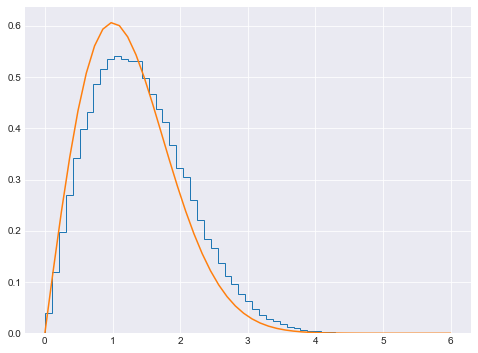

In [40]:
num_samples = 100000
dist_mean1 = [0,0]
dist_mean2 = [5,0]
unc1 = [48, 6, 0.4]
unc2 = [3, 4, -0.1]

error_normalized_distances = simulate_error_normalized_distance(dist_mean1, dist_mean2, unc1, unc2, num_samples, method='full')

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot()

ax.hist(error_normalized_distances, bins=50, histtype='step', density=True)
x = np.linspace(0,6,50)
ax.plot(x, rayleigh(x,1))
plt.show()